In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import warnings
warnings.filterwarnings('ignore')

In [32]:
file = r"C:\Users\Catarina\Documents\mestrado\2nd semester\business cases\Case2_data_extract_share.xlsx"
file2 = r"C:\Users\Catarina\Documents\mestrado\2nd semester\business cases\Case2_market_data_share.xlsx"

market_data = pd.read_excel(file2, engine="calamine")

# Sheet de treino (a que já estamos a usar por defeito)
data_train = pd.read_excel(file, sheet_name="training", engine="calamine")

# Sheet de validação
data_val = pd.read_excel(file, sheet_name="validation", engine="calamine")


print("data_train:", data_train.shape)
print("data_val:", data_val.shape)
print("market_data:", market_data.shape)

data_train: (4237, 7)
data_val: (715, 7)
market_data: (180, 78)


## 1. Overview of the Datasets

In [33]:
data_train.head()

,Anon Period,TGL Biz Desc,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon)
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277
1,2,SSI,SSI027,SSI02710,SSI02710,0,334
2,3,SSI,SSI027,SSI02710,SSI02710,0,334
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112


In [34]:
data_train.info()
data_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Anon Period              4237 non-null   int64 
 1   TGL Biz Desc             4237 non-null   object
 2   TGL Business Unit        4237 non-null   object
 3   TGL Business Segment     4237 non-null   object
 4   TGL Business Subsegment  4237 non-null   object
 5   Orders cons. (anon)      4237 non-null   int64 
 6   Revenue cons. (anon)     4237 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 231.8+ KB


,Anon Period,Orders cons. (anon),Revenue cons. (anon)
count,4237.000000,4.237000e+03,4.237000e+03
mean,22.510031,4.007662e+07,3.597641e+07
std,12.238664,7.041486e+07,6.378604e+07
min,1.000000,-5.610188e+07,-1.201076e+07
25%,12.000000,8.713890e+05,1.020192e+06
50%,23.000000,9.281978e+06,8.850535e+06
75%,33.000000,4.331285e+07,3.646013e+07
max,42.000000,5.950944e+08,4.200361e+08


In [35]:
market_data.info()
market_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 78 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    180 non-null    int64  
 1   China_Core_Inflation_Rate                 178 non-null    float64
 2   China_Exports                             178 non-null    float64
 3   China_GDP                                 15 non-null     float64
 4   China_GDP_from_Construction               60 non-null     float64
 5   China_GDP_from_Manufacturing              60 non-null     float64
 6   China_Industrial_Production               176 non-null    float64
 7   China_Industrial_Production_Mom           170 non-null    float64
 8   China_Inflation_Rate                      178 non-null    float64
 9   China_Interest_Rate                       137 non-null    float64
 10  China_Steel_Production                

,Period,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
count,180.000000,178.000000,178.000000,15.000000,60.000000,60.000000,176.000000,170.000000,178.000000,137.000000,...,178.000000,178.000000,15.000000,60.000000,60.000000,178.000000,178.000000,178.000000,175.000000,180.000000
mean,-41.500000,1.374719,215.888202,13031.133333,33122.373333,173068.405000,7.422443,0.650294,2.076966,4.205255,...,2.587079,209.068730,20549.852667,719.746667,2129.463333,1.034831,0.074157,2.600000,1.425714,6908.792167
std,52.105662,0.599323,56.051736,4130.317309,22602.805168,96035.072098,5.041883,3.290186,1.485097,0.693721,...,1.399758,31.897784,4404.146086,143.697943,148.434035,3.864750,1.333110,1.978843,1.748824,529.050254
min,-131.000000,-0.300000,80.380000,6192.560000,4749.000000,42670.300000,-13.500000,-22.100000,-0.800000,3.100000,...,0.600000,147.143000,15048.970000,533.200000,1906.300000,-17.200000,-13.200000,-0.200000,0.250000,4746.000000
25%,-86.250000,0.900000,177.787500,10208.825000,13793.250000,93960.050000,5.400000,0.442500,1.300000,3.700000,...,1.700000,188.111750,17244.410000,572.325000,2000.150000,-0.975000,-0.275000,1.425000,0.250000,6648.247500
50%,-41.500000,1.500000,204.655000,12537.560000,28693.250000,163199.350000,6.300000,0.550000,2.000000,4.300000,...,2.100000,198.925000,19612.100000,654.100000,2104.350000,1.600000,0.100000,2.100000,0.250000,6955.495000
75%,3.250000,1.800000,263.342500,16599.055000,47756.275000,227774.975000,9.050000,0.755000,2.700000,4.310000,...,3.175000,215.553500,22610.575000,867.675000,2251.675000,3.175000,0.500000,3.075000,2.000000,7270.157500
max,48.000000,2.500000,339.660000,18743.800000,88862.800000,404518.500000,35.100000,36.560000,6.500000,5.770000,...,6.600000,283.269000,29184.890000,904.400000,2389.000000,16.100000,6.600000,9.100000,5.500000,7960.900000


In [36]:
#checking number of missing values
market_data.isna().sum()

Period                                       0
China_Core_Inflation_Rate                    2
China_Exports                                2
China_GDP                                  165
China_GDP_from_Construction                120
                                          ... 
United_States_Industrial_Production          2
United_States_Industrial_Production_Mom      2
United_States_Inflation_Rate                 2
United_States_Interest_Rate                  5
United_States_Steel_Production               0
Length: 78, dtype: int64

## 2. Data Extract — Orders & Revenue over Time

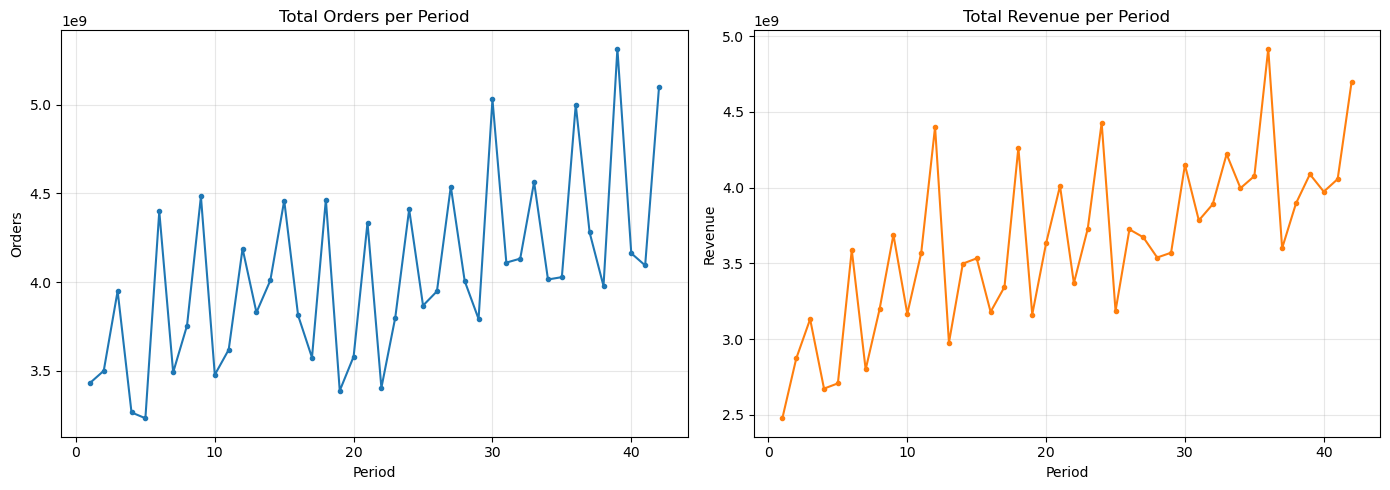

In [37]:
# Aggregate Orders and Revenue by period
agg_by_period = data_train.groupby("Anon Period")[["Orders cons. (anon)", "Revenue cons. (anon)"]].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(agg_by_period.index, agg_by_period["Orders cons. (anon)"], marker="o", markersize=3)
axes[0].set_title("Total Orders per Period")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Orders")
axes[0].grid(True, alpha=0.3)

axes[1].plot(agg_by_period.index, agg_by_period["Revenue cons. (anon)"], marker="o", markersize=3, color="tab:orange")
axes[1].set_title("Total Revenue per Period")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Revenue")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

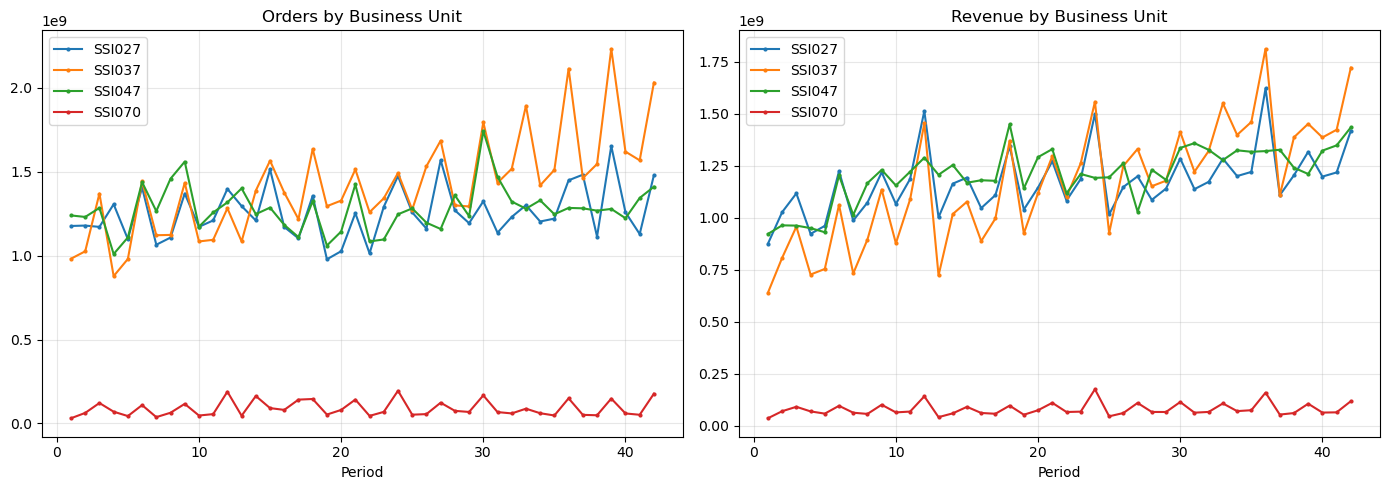

In [38]:
# Orders and Revenue by Business Unit over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for unit in data_train["TGL Business Unit"].unique():
    subset = data_train[data_train["TGL Business Unit"] == unit]
    agg = subset.groupby("Anon Period")[["Orders cons. (anon)", "Revenue cons. (anon)"]].sum()
    axes[0].plot(agg.index, agg["Orders cons. (anon)"], label=unit, marker="o", markersize=2)
    axes[1].plot(agg.index, agg["Revenue cons. (anon)"], label=unit, marker="o", markersize=2)

axes[0].set_title("Orders by Business Unit")
axes[0].set_xlabel("Period")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Revenue by Business Unit")
axes[1].set_xlabel("Period")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

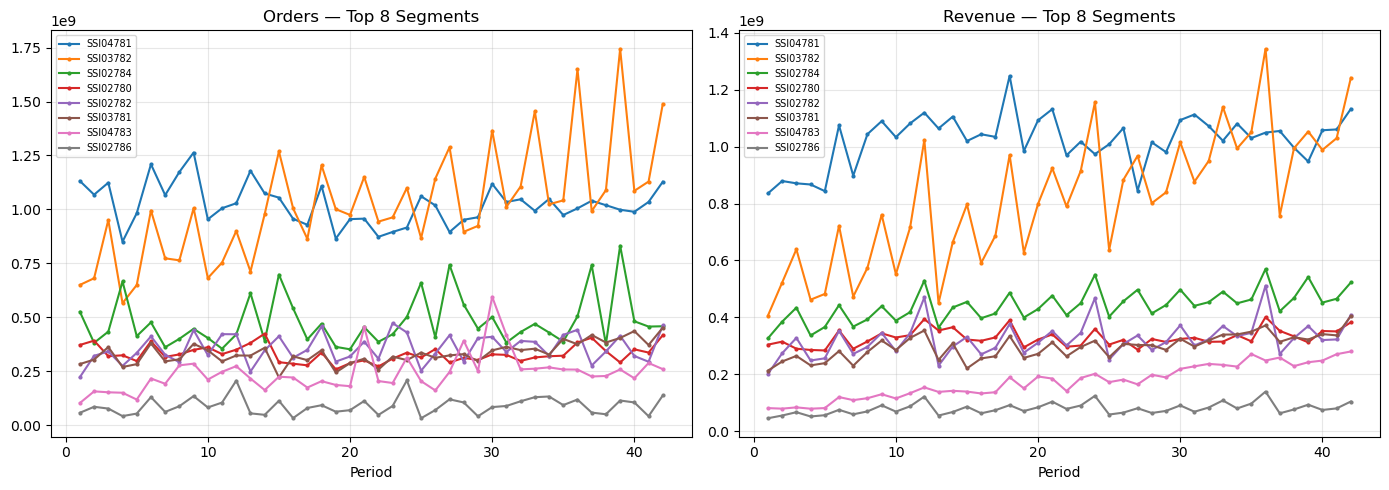

In [39]:
# Top 8 Business Segments by total Revenue
top_segments = (
    data_train.groupby("TGL Business Segment")["Revenue cons. (anon)"]
    .sum()
    .nlargest(8)
    .index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for seg in top_segments:
    subset = data_train[data_train["TGL Business Segment"] == seg]
    agg = subset.groupby("Anon Period")[["Orders cons. (anon)", "Revenue cons. (anon)"]].sum()
    axes[0].plot(agg.index, agg["Orders cons. (anon)"], label=seg, marker="o", markersize=2)
    axes[1].plot(agg.index, agg["Revenue cons. (anon)"], label=seg, marker="o", markersize=2)

axes[0].set_title("Orders — Top 8 Segments")
axes[0].set_xlabel("Period")
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Revenue — Top 8 Segments")
axes[1].set_xlabel("Period")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

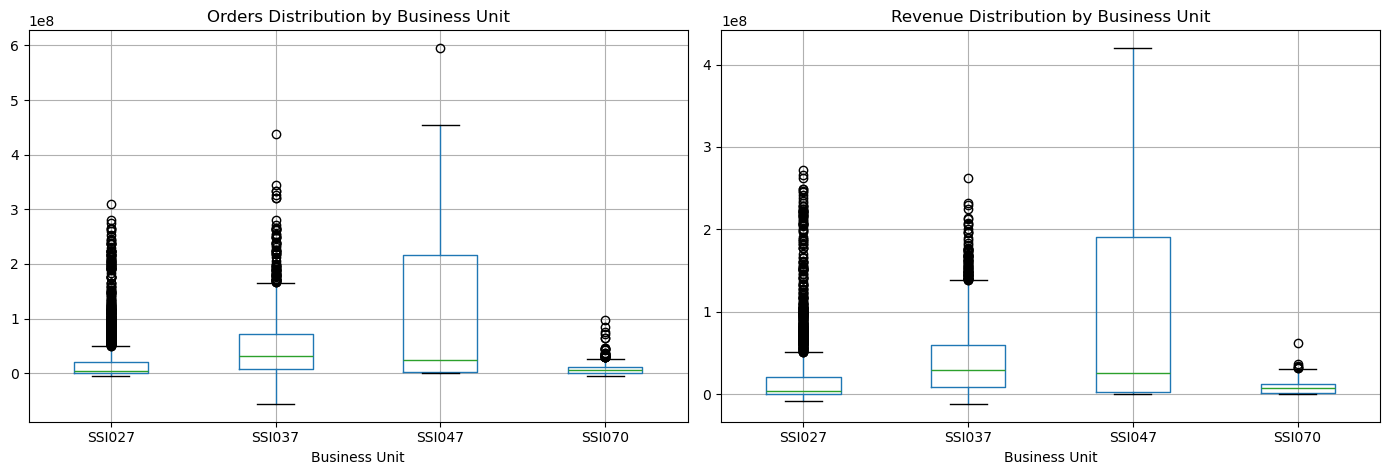

In [40]:
# Distribution of Orders and Revenue by Business Unit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_train.boxplot(column="Orders cons. (anon)", by="TGL Business Unit", ax=axes[0])
axes[0].set_title("Orders Distribution by Business Unit")
axes[0].set_xlabel("Business Unit")

data_train.boxplot(column="Revenue cons. (anon)", by="TGL Business Unit", ax=axes[1])
axes[1].set_title("Revenue Distribution by Business Unit")
axes[1].set_xlabel("Business Unit")

fig.suptitle("")
plt.tight_layout()
plt.show()

## 3. Market Data — Macroeconomic Indicators

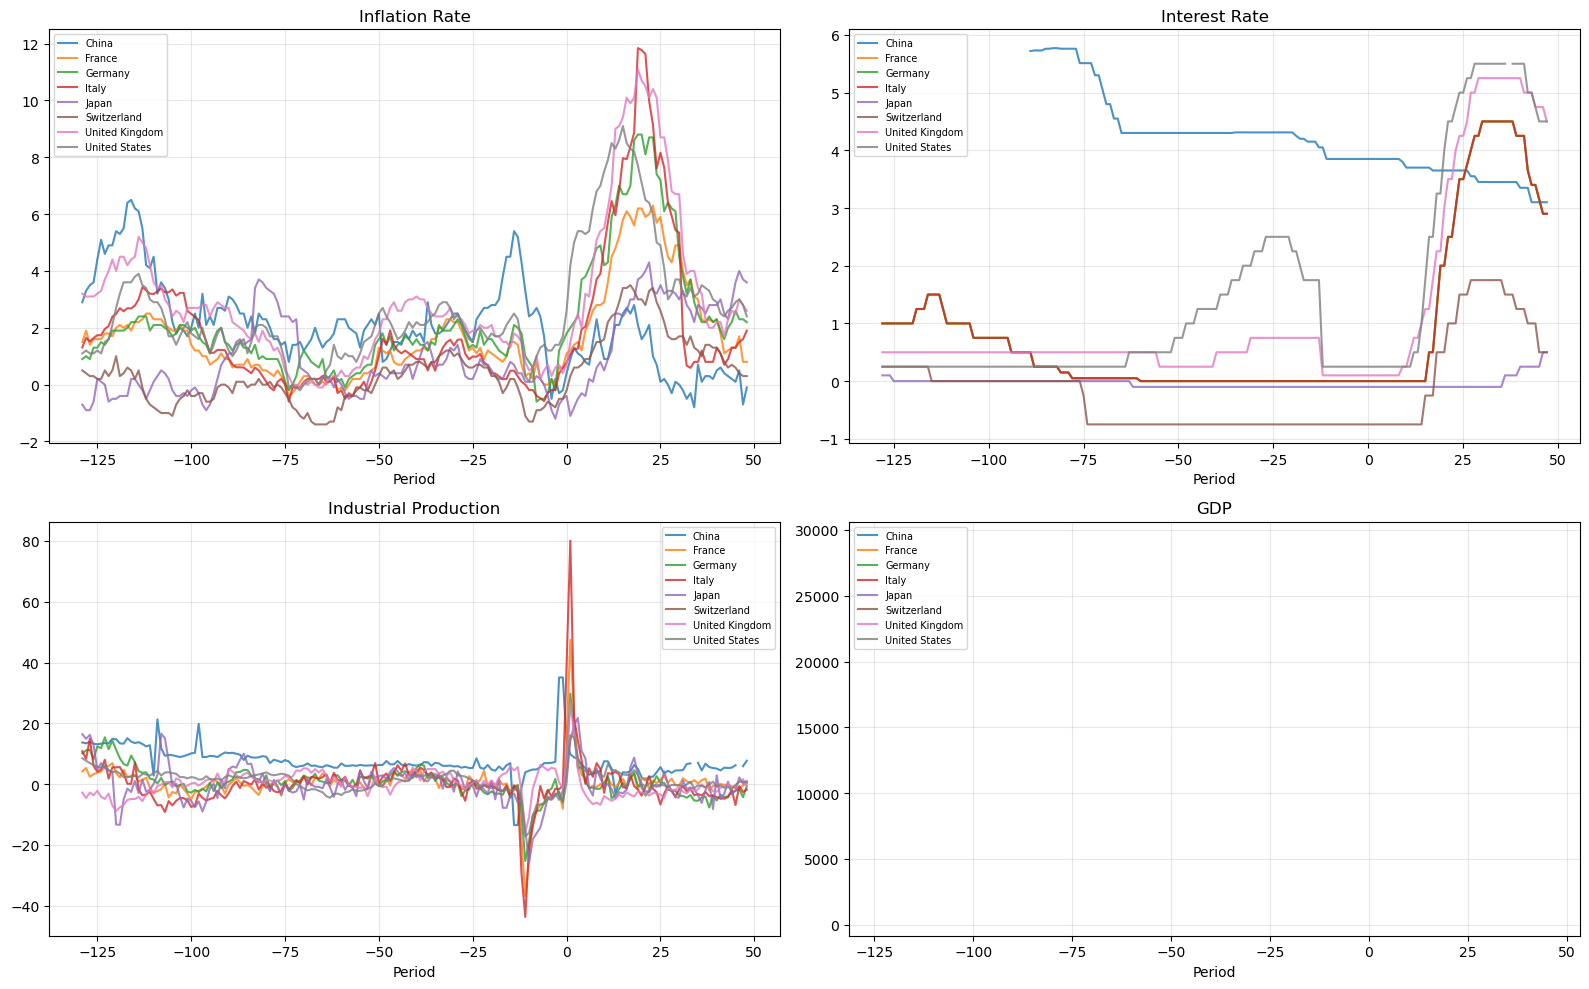

In [41]:
# Compare key indicators across countries
countries = ["China", "France", "Germany", "Italy", "Japan", "Switzerland", "United_Kingdom", "United_States"]
indicators = ["Inflation_Rate", "Interest_Rate", "Industrial_Production", "GDP"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, indicator in enumerate(indicators):
    for country in countries:
        col = f"{country}_{indicator}"
        if col in market_data.columns:
            axes[i].plot(market_data["Period"], market_data[col], label=country.replace("_", " "), alpha=0.8)
    axes[i].set_title(indicator.replace("_", " "))
    axes[i].set_xlabel("Period")
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

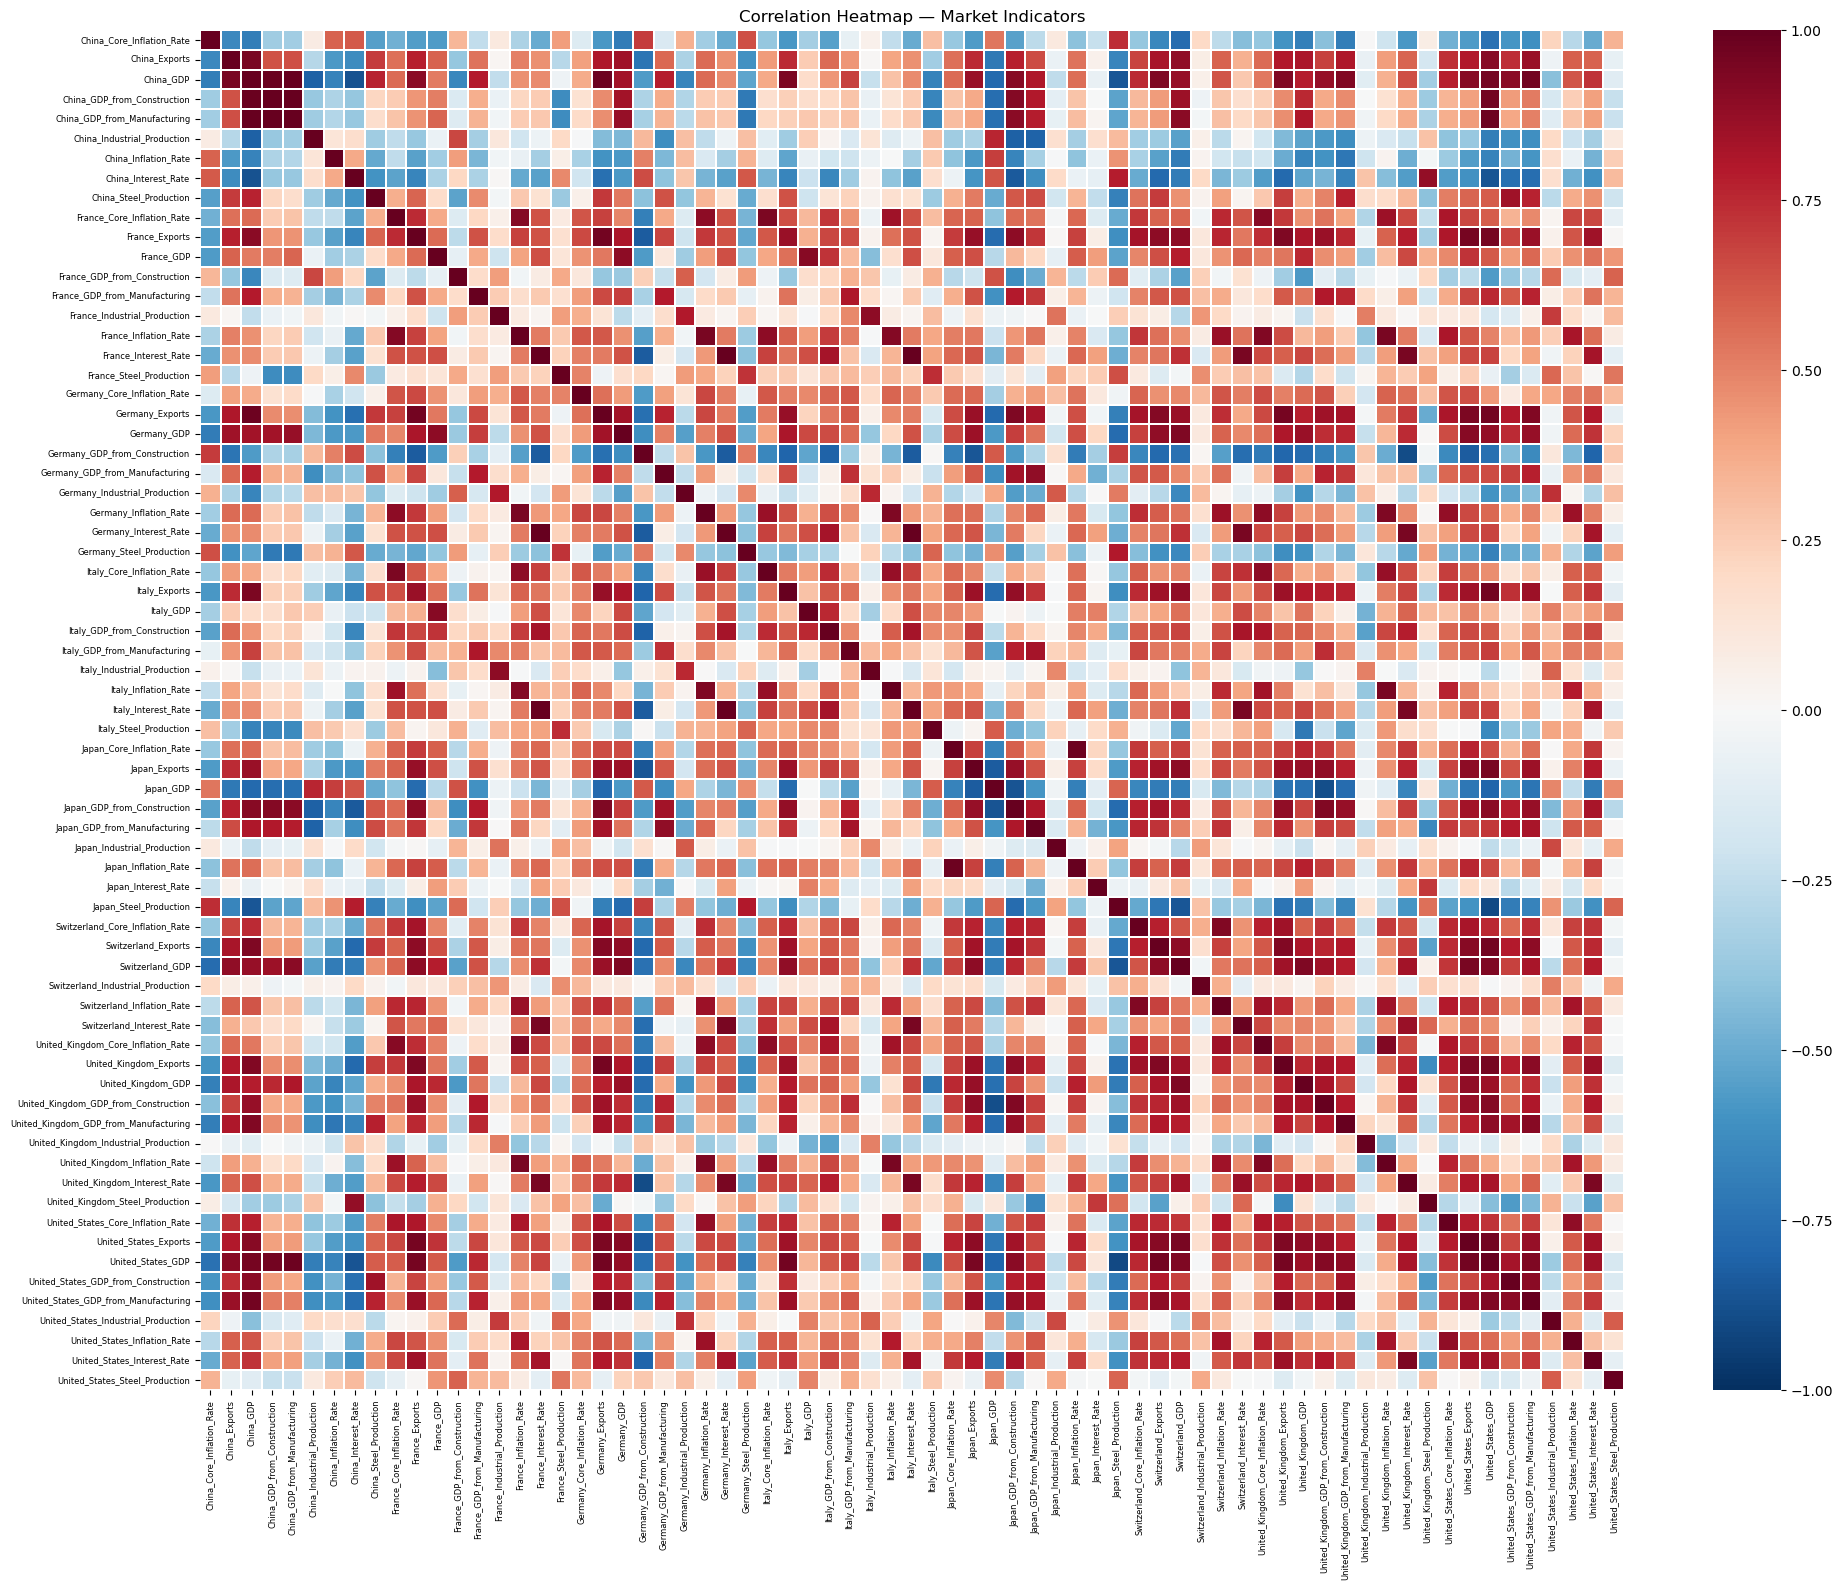

In [42]:
# Correlation heatmap of market indicators (sample of key columns to keep readable)
key_cols = [col for col in market_data.columns if col != "Period" and not col.endswith("_Mom")]
corr = market_data[key_cols].corr()

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, 
            xticklabels=True, yticklabels=True, ax=ax,
            linewidths=0.1, fmt=".1f")
ax.set_title("Correlation Heatmap — Market Indicators")
ax.tick_params(axis="both", labelsize=6)
plt.tight_layout()
plt.show()

## 4. Trend & Seasonality Decomposition

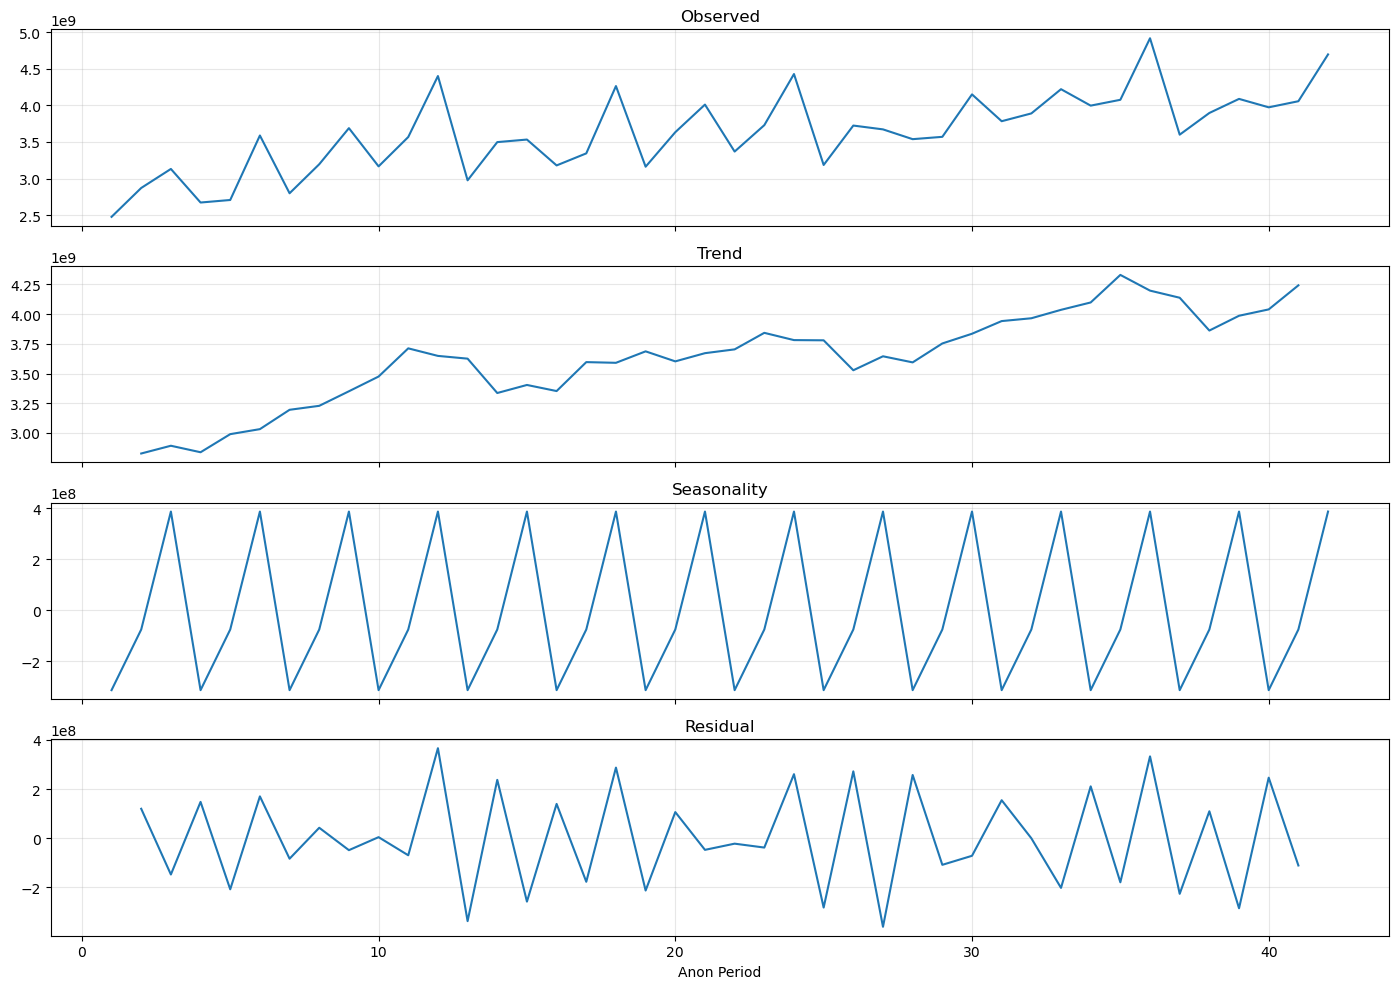

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose total Revenue over time
revenue_ts = agg_by_period["Revenue cons. (anon)"]

# Try period=12 (monthly seasonality if periods are months); adjust if needed
# With 42 periods, period=6 also works for semi-annual patterns
decomp = seasonal_decompose(revenue_ts, model="additive", period=6)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title="Observed")
decomp.trend.plot(ax=axes[1], title="Trend")
decomp.seasonal.plot(ax=axes[2], title="Seasonality")
decomp.resid.plot(ax=axes[3], title="Residual")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

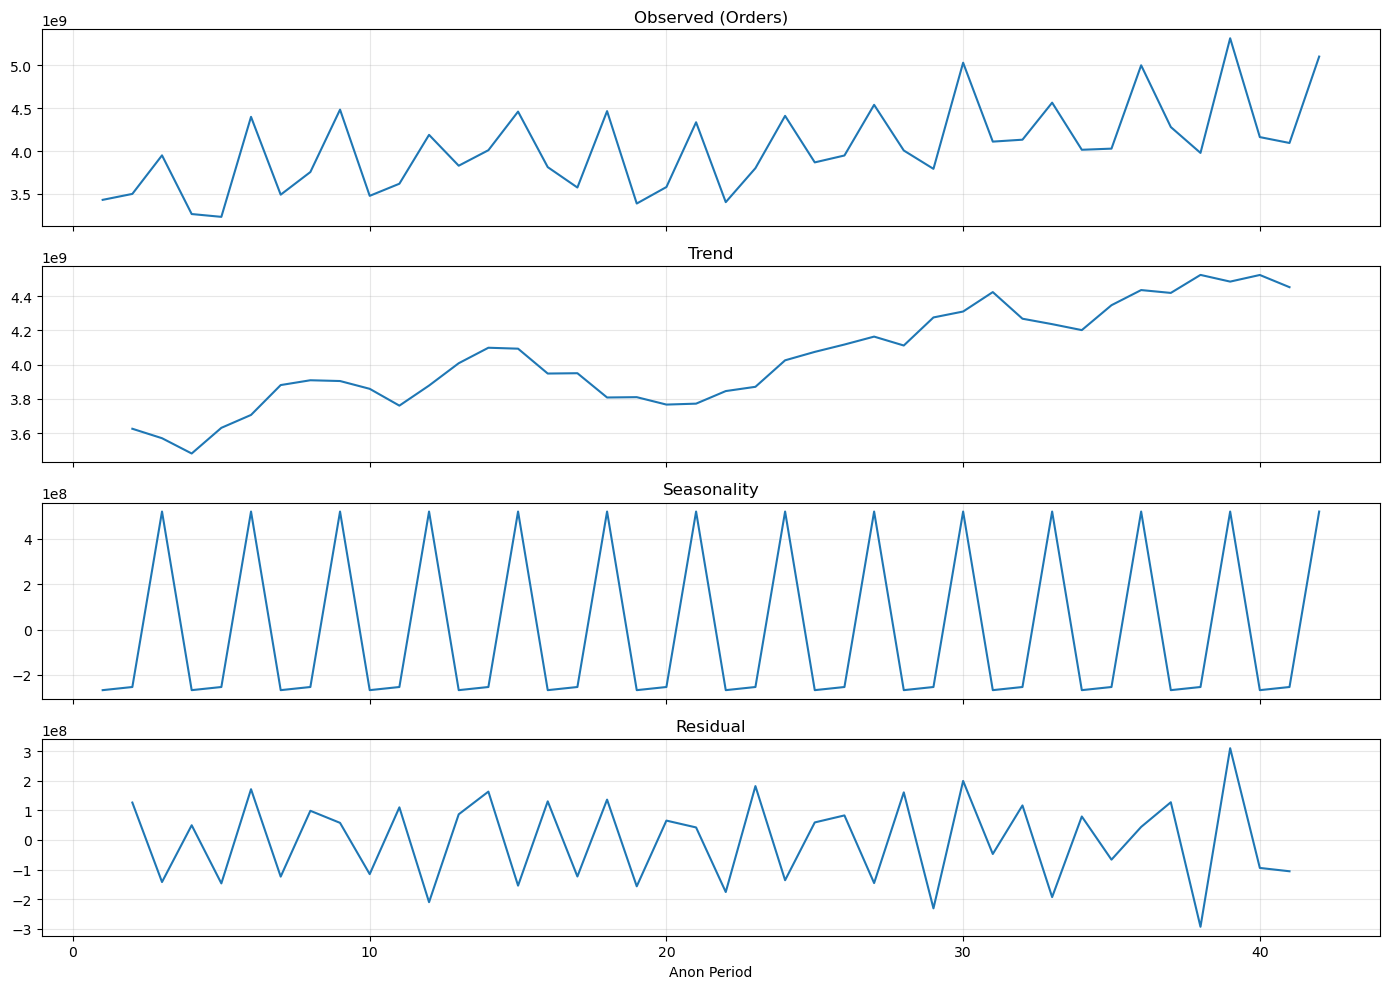

In [44]:
# Same decomposition for Orders
orders_ts = agg_by_period["Orders cons. (anon)"]
decomp_orders = seasonal_decompose(orders_ts, model="additive", period=3)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp_orders.observed.plot(ax=axes[0], title="Observed (Orders)")
decomp_orders.trend.plot(ax=axes[1], title="Trend")
decomp_orders.seasonal.plot(ax=axes[2], title="Seasonality")
decomp_orders.resid.plot(ax=axes[3], title="Residual")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

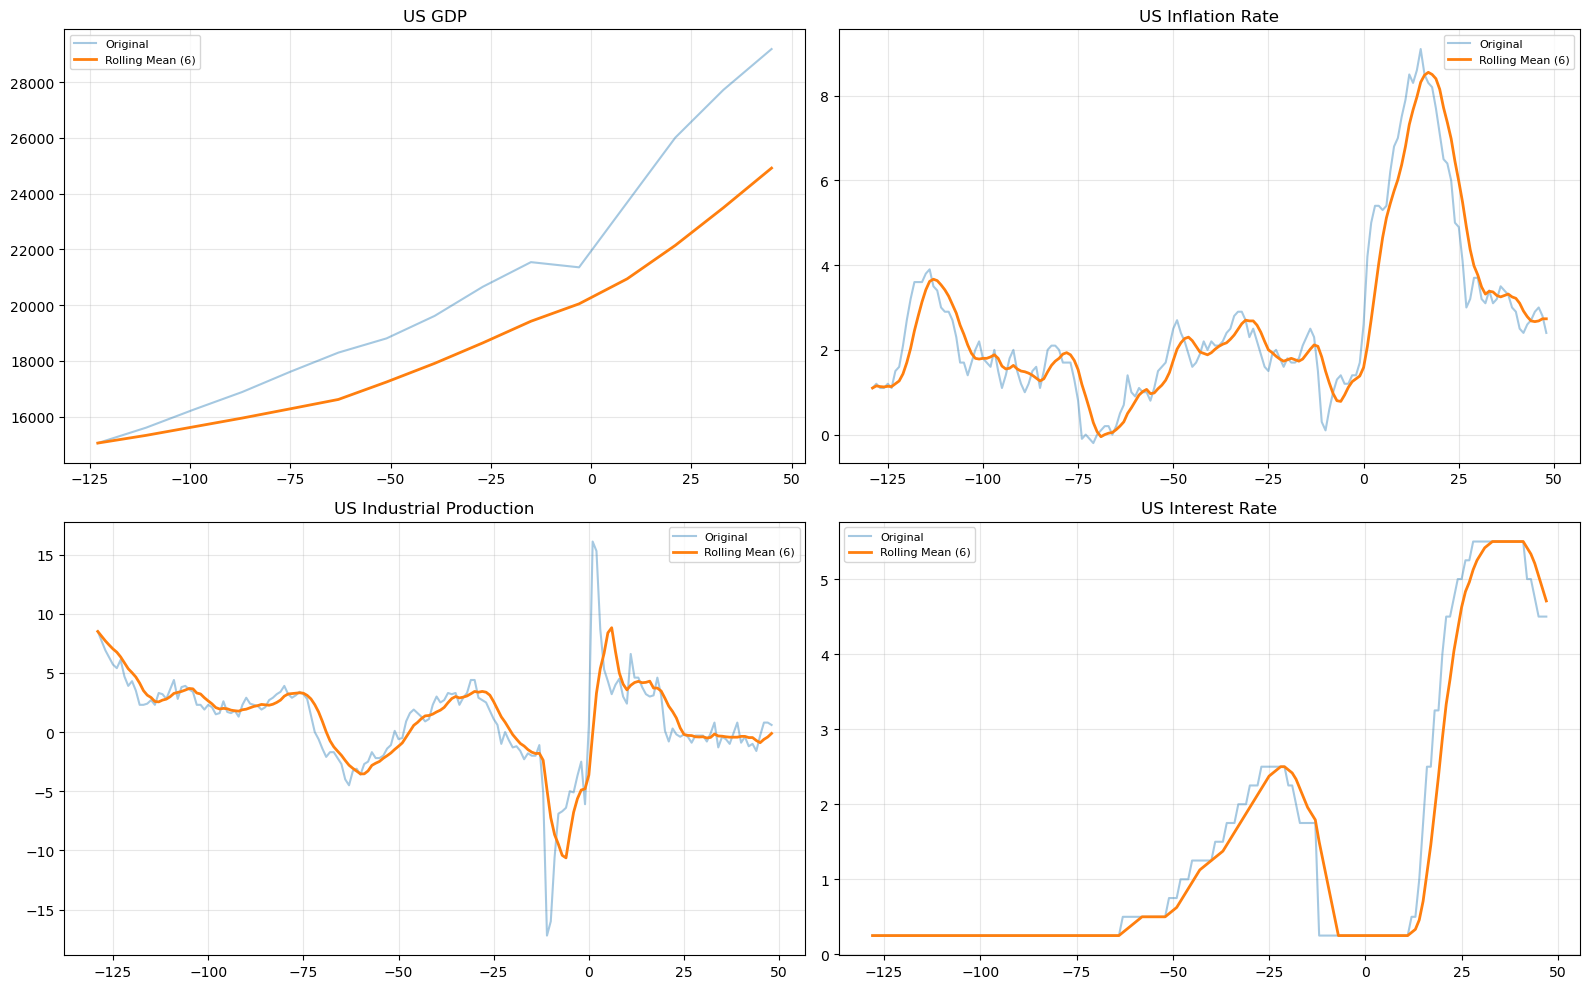

In [45]:
# Rolling averages on key market indicators (US as example)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

us_indicators = ["United_States_GDP", "United_States_Inflation_Rate", 
                 "United_States_Industrial_Production", "United_States_Interest_Rate"]

for i, col in enumerate(us_indicators):
    series = market_data.set_index("Period")[col].dropna()
    axes[i].plot(series.index, series.values, alpha=0.4, label="Original")
    axes[i].plot(series.index, series.rolling(6, min_periods=1).mean(), 
                 linewidth=2, label="Rolling Mean (6)")
    axes[i].set_title(col.replace("United_States_", "US ").replace("_", " "))
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Relationship between Datasets

In [46]:
# Align datasets: data periods 1-42 should match market_data periods 1-42
market_overlap = market_data[market_data["Period"].between(1, 42)].set_index("Period")

# Merge with aggregated company data
combined = agg_by_period.join(market_overlap, how="inner")
print(f"Combined shape: {combined.shape}")
print(f"Periods matched: {combined.index.min()} to {combined.index.max()}")
combined.head()

Combined shape: (42, 79)
Periods matched: 1 to 42


,Orders cons. (anon),Revenue cons. (anon),China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
Anon Period,,,,,,,,,,,,,,,,,,,,,
1,3430374690,2476687689,0.7,263.09,NaN,NaN,NaN,9.8,0.52,0.9,...,3.0,209.117,NaN,NaN,NaN,16.1,0.1,4.2,0.25,6900.0
2,3499678788,2871405827,0.9,263.23,NaN,NaN,NaN,8.8,0.45,1.3,...,3.8,211.641,NaN,NaN,NaN,15.3,0.9,5.0,0.25,7200.0
3,3949155294,3131347665,0.9,280.30,NaN,32730.0,172698.4,8.3,0.48,1.1,...,4.5,214.009,NaN,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0
4,3264950469,2672503014,1.3,281.28,NaN,NaN,NaN,6.4,0.21,1.0,...,4.3,216.286,NaN,NaN,NaN,5.3,0.4,5.4,0.25,7500.0
5,3232137256,2707163488,1.2,293.17,NaN,NaN,NaN,5.3,0.30,0.8,...,4.0,217.728,NaN,NaN,NaN,4.3,0.0,5.3,0.25,7500.0


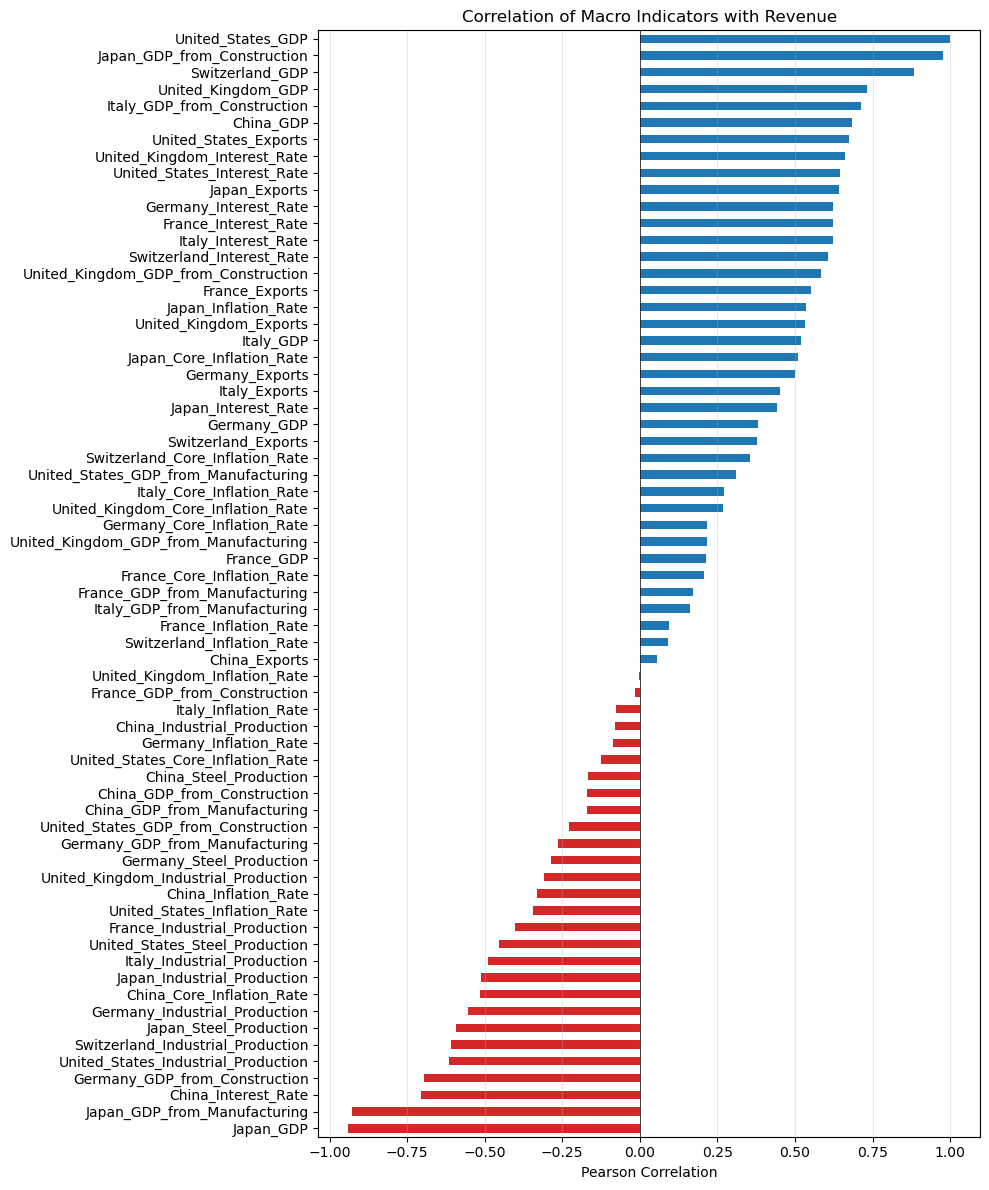

In [47]:
# Correlation of Revenue/Orders with key macro indicators
macro_cols = [c for c in combined.columns if c not in ["Orders cons. (anon)", "Revenue cons. (anon)"] and not c.endswith("_Mom")]
corr_with_revenue = combined[macro_cols].corrwith(combined["Revenue cons. (anon)"]).dropna().sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
corr_with_revenue.plot(kind="barh", ax=ax, color=corr_with_revenue.apply(lambda x: "tab:blue" if x >= 0 else "tab:red"))
ax.set_title("Correlation of Macro Indicators with Revenue")
ax.set_xlabel("Pearson Correlation")
ax.axvline(x=0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

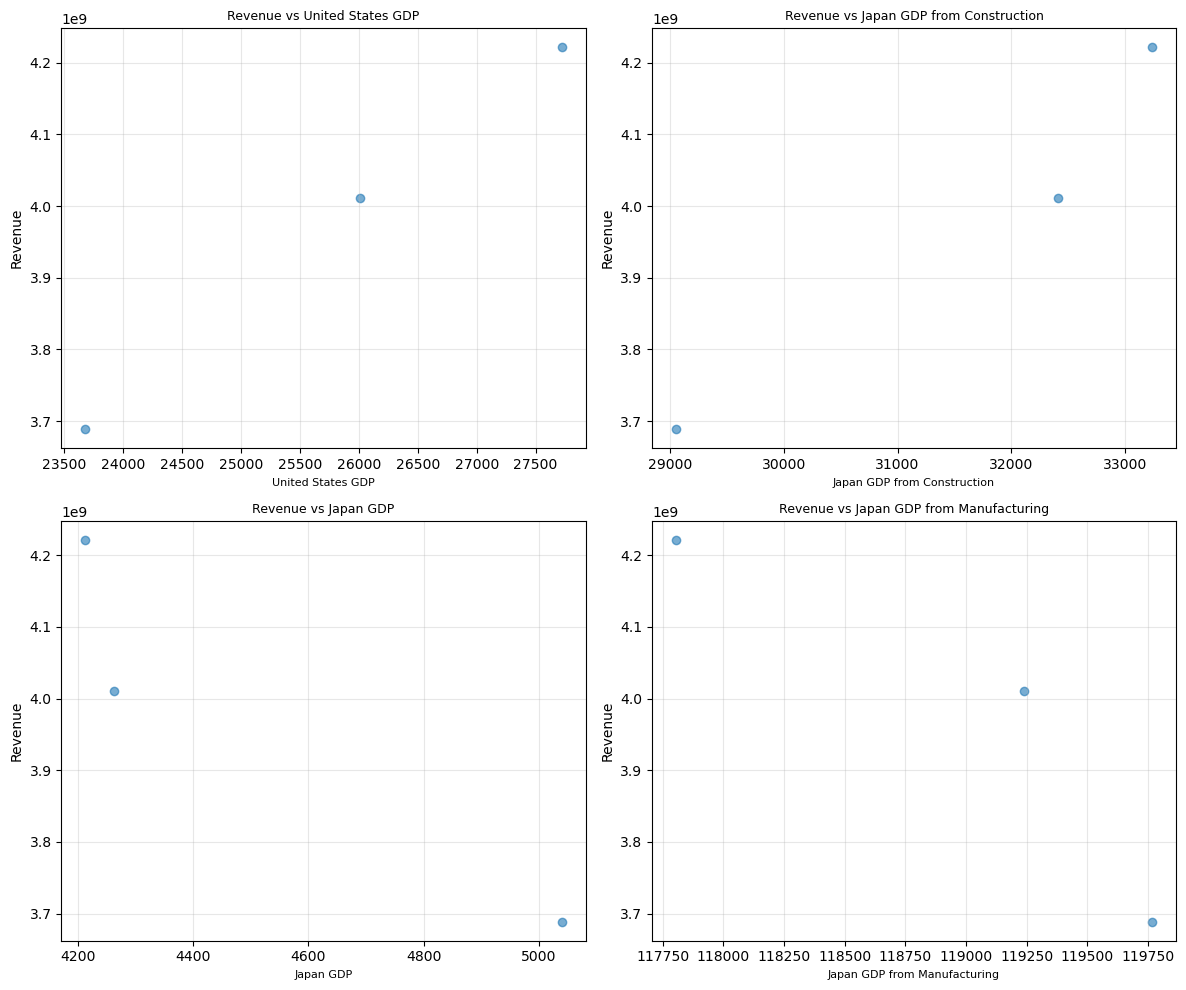

In [48]:
# Scatter plots: Revenue vs top 4 most correlated macro indicators
top_corr = corr_with_revenue.abs().nlargest(4).index

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(top_corr):
    axes[i].scatter(combined[col], combined["Revenue cons. (anon)"], alpha=0.6)
    axes[i].set_xlabel(col.replace("_", " "), fontsize=8)
    axes[i].set_ylabel("Revenue")
    axes[i].set_title(f"Revenue vs {col.replace('_', ' ')}", fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()